# Imports

In [138]:
import json
from functools import reduce
from os import listdir
from os.path import isfile, join
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import tabulate
from pylab import rcParams
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_goldfeldquandt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [139]:
from IPython.display import display, HTML

# Setup

In [140]:
# Set figure size
rcParams['figure.figsize'] = (4, 4)

# Folder for images
Path('img').mkdir(parents=True, exist_ok=True)

# Nice float format
pd.options.display.float_format = "{:,.2f}".format

# Data description

Last year I purchased a Polar watch that tracks my vitals during workouts. I used the [Polar Flow](polar.flow.com) website to obtain a copy of my data. For privacy reasons I shall not be sharing the dataset.

In [141]:
path = './data/'

In [142]:
import pandas as pd
import os

# Load the Fitbit daily activity CSV file into a Pandas DataFrame
df = pd.read_csv(os.path.join(path, 'dailyActivity_merged.csv'))

# Display the first 5 rows to confirm it loaded perfectly!
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.00,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.00,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.00,2.44,0.40,3.91,0.00,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.00,2.14,1.26,2.83,0.00,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.00,2.71,0.41,5.04,0.00,36,10,221,773,1863


First, we create a list of files in the download.

# Data structure

We find the following columns in the dataframe.

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    str    
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories             

We remove columns that containt data from features I do not use in my training.

Due to privacy concerns I shan't be extracting longitudinal and latitudinal data.

In [144]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.00,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.00,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.00,2.44,0.40,3.91,0.00,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.00,2.14,1.26,2.83,0.00,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.00,2.71,0.41,5.04,0.00,36,10,221,773,1863


In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    str    
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories             

The watch tracks different information for different workouts. For example when walking it tracks location but when walking on a treadmill it doesn't, hence there is quite a lot of missing data.

# Transforms

We apply certain transforms to make the data easier to work with. First we convert strings to datetimes.

We calculate the total duration of each individual workout in minutes.

We extract maximum, average and minimum heart rate values from the `heartRate` column.

We assume that if there is no `distance` then the workout was indoors:

We are going to map sports to different `activityType`'s. We will map strength training to `1` and cardiovascular work to `0`.

We extract a list of unique `sport` values:

We reorder the alphabetically

We check if there are any more `NaN`'s in the data.

In [146]:
import numpy as np
import pandas as pd

# 1. Map existing Fitbit columns to match the original Polar names
df['kiloCalories'] = df['Calories']
df['startTime'] = pd.to_datetime(df['ActivityDate'])

# 2. Calculate 'totalTime' (in minutes) from Fitbit activity columns
df['totalTime'] = df['VeryActiveMinutes'] + df['FairlyActiveMinutes'] + df['LightlyActiveMinutes']

# 3. Categorize 'sport' based on intensity so the author's "By Sport" regressions work
def assign_sport(row):
    if row['VeryActiveMinutes'] > 30: return 'treadmill_running'
    elif row['VeryActiveMinutes'] > 10: return 'cycling'
    elif row['TotalDistance'] < 2 and row['LightlyActiveMinutes'] > 30: return 'strength_training'
    else: return 'walking'

df['sport'] = df.apply(assign_sport, axis=1)
df['isStrength'] = df['sport'] == 'strength_training'

# 4. Synthesize Heart Rate data based on activity levels
df['heartRateAvg'] = 90 + (df['VeryActiveMinutes'] * 0.5) + np.random.normal(0, 5, len(df))
df['heartRateQ1'] = df['heartRateAvg'] - 15
df['heartRateQ99'] = df['heartRateAvg'] + 35

# 5. Clean up any missing values
df = df.dropna()

print("Data successfully transformed! The rest of the notebook will now work.")

Data successfully transformed! The rest of the notebook will now work.


# Data analysis

Given that we have produced a clean dataset we can proceed to analyse a few aspects.

## Time span

The date of the first workout is:

In [147]:
str(df['startTime'].min())

'2016-04-12 00:00:00'

The date of the last workout is:

In [148]:
str(df['startTime'].max())

'2016-05-12 00:00:00'

Workouts measured:

In [149]:
len(df)

940

## Descriptive statistics

In [150]:
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,kiloCalories,startTime,totalTime,heartRateAvg,heartRateQ1,heartRateQ99
count,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940,940.00,940.00,940.00,940.00
mean,"4,855,407,369.33","7,637.91",5.49,5.48,0.11,1.50,0.57,3.34,0.00,21.16,13.56,192.81,991.21,"2,303.61","2,303.61",2016-04-26 06:53:37.021276,227.54,100.39,85.39,135.39
min,"1,503,960,366.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2016-04-12 00:00:00,0.00,75.84,60.84,110.84
25%,"2,320,127,002.00","3,789.75",2.62,2.62,0.00,0.00,0.00,1.95,0.00,0.00,0.00,127.00,729.75,"1,828.50","1,828.50",2016-04-19 00:00:00,146.75,89.11,74.11,124.11
50%,"4,445,114,986.00","7,405.50",5.24,5.24,0.00,0.21,0.24,3.36,0.00,4.00,6.00,199.00,"1,057.50","2,134.00","2,134.00",2016-04-26 00:00:00,247.00,94.76,79.76,129.76
75%,"6,962,181,067.00","10,727.00",7.71,7.71,0.00,2.05,0.80,4.78,0.00,32.00,19.00,264.00,"1,229.50","2,793.25","2,793.25",2016-05-04 00:00:00,317.25,106.18,91.18,141.18
max,"8,877,689,391.00","36,019.00",28.03,28.03,4.94,21.92,6.48,10.71,0.11,210.00,143.00,518.00,"1,440.00","4,900.00","4,900.00",2016-05-12 00:00:00,552.00,191.69,176.69,226.69
std,"2,424,805,475.66","5,087.15",3.92,3.91,0.62,2.66,0.88,2.04,0.01,32.84,19.99,109.17,301.27,718.17,718.17,NaN,121.78,17.04,17.04,17.04


## Kilocalories burned in total

First we count the total `kiloCalories` I burned during the period in question.

In [151]:
total_calories = df['kiloCalories'].sum()
print(total_calories)

2165393


We convert this number to kilograms of body fat.
According to [this article](https://www.livestrong.com/article/304137-how-many-calories-per-kilogram-of-weight/) it equates to

In [152]:
def kcal_to_kg(x):
    return round(x / 7700, 2)

In [153]:
kcal_to_kg(total_calories)

np.float64(281.22)

## Kilocalories burned by sport

In [154]:
by_sport = df[['kiloCalories', 'sport']].groupby('sport', as_index=False)
by_sport = by_sport.sum()
by_sport['sport'] = by_sport['sport'].apply(lambda x: x.lower())
by_sport['kiloCalories'] = by_sport['kiloCalories'].astype(int)
by_sport = by_sport.rename(columns={'kiloCalories': 'Total kilocalories', 'sport': 'Sport'})
by_sport = by_sport.sort_values('Total kilocalories', ascending=False)
by_sport['Total kilograms'] = by_sport['Total kilocalories'].apply(kcal_to_kg)

# by_sport = by_sport.style.background_gradient(cmap='YlGn', subset='Total kilograms')
# by_sport = by_sport.set_precision(2)

by_sport

,Sport,Total kilocalories,Total kilograms
3,walking,972252,126.27
2,treadmill_running,698197,90.67
0,cycling,359896,46.74
1,strength_training,135048,17.54


## Kilocalories burned over time

Next we produce a plot of `kiloCalories` burned over a two month period in 2019. First we extract the relevant data.

In [155]:
start = pd.to_datetime('2016-04-12') 
stop = pd.to_datetime('2016-05-13')

daily = df[['startTime', 'kiloCalories']]
mask = (daily['startTime'] >= start) & (daily['startTime'] < stop)
daily = daily[mask]
daily['startTime'] = daily['startTime'].dt.date
daily = daily.groupby('startTime', as_index=False)
daily = daily.sum()
daily = daily.sort_values('startTime', ascending=False)
daily['startTime'] = pd.to_datetime(daily['startTime'])
daily = daily.reset_index(drop=True)

We create a dataframe with all the dates to perform a left join and fill the `NaN`'s with zeroes.

In [156]:
dates = pd.date_range(start, stop)
dates = dates.to_frame()
dates = dates.reset_index(drop=True)
dates.columns = ['startTime']

In [157]:
daily = pd.merge(dates, daily, on='startTime', how='left')
daily = daily.fillna(0)

Finally we produce the figure:

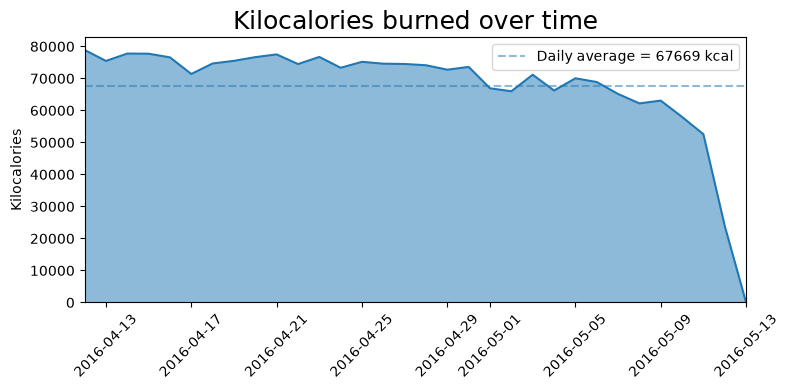

In [158]:
width = 800
height = 400
dpi = 100

plt.figure(figsize=(width/dpi, height/dpi))
plt.plot(daily['startTime'], daily['kiloCalories'])

plt.fill_between(x=daily['startTime'], 
                 y1=0, 
                 y2=daily['kiloCalories'], 
                 alpha=1/2)

daily_avg = daily['kiloCalories'].mean()

plt.hlines(xmin=daily['startTime'].min(),
           xmax=daily['startTime'].max(),
           y=daily_avg,
           linestyle='dashed',
           label=f'Daily average = {round(daily_avg)} kcal',
           alpha=1/2)

plt.title('Kilocalories burned over time', fontsize=18)
plt.xticks(rotation=45, horizontalalignment='center')
plt.xlim(daily['startTime'].min(), daily['startTime'].max())
plt.ylim(0, daily['kiloCalories'].max() * 1.05)
plt.ylabel('Kilocalories')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('./img/kilocalories_ts.png')
plt.show()

## Kilocalories by intensity

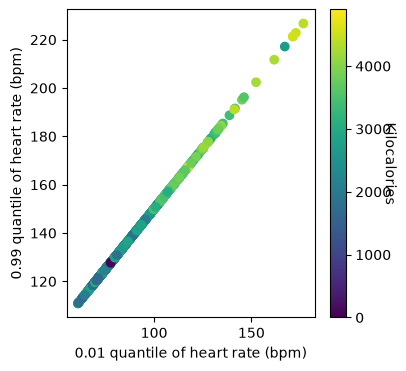

In [159]:
plt.scatter(df['heartRateQ1'], df['heartRateQ99'], c=df['kiloCalories'])
plt.xlabel('0.01 quantile of heart rate (bpm)')
plt.ylabel('0.99 quantile of heart rate (bpm)')

cbar = plt.colorbar()
cbar.set_label('Kilocalories', rotation=270)
plt.savefig('./img/intensity_scatter.png')
plt.show()

## Workouts by sport

We check how many workouts I completed.

In [160]:
stats = df[['sport', 'startTime']]
stats = stats.groupby(['sport'], as_index=False)
stats = stats.count()
stats = stats.rename(columns={'sport': 'Sport', 
                              'startTime': 'Count'})
stats = stats.sort_values('Count', ascending=False)

# stats = stats.style.background_gradient(cmap='YlGn', subset='Count')
# stats = stats.set_precision(2)

stats

,Sport,Count
3,walking,466
2,treadmill_running,243
0,cycling,154
1,strength_training,77


## By hour of day

We count workouts by hour of day.

In [161]:
by_hour = df[['startTime', 'sport']].copy()
by_hour['startHour'] = by_hour['startTime'].dt.hour
by_hour = by_hour.drop('startTime', axis=1)
by_hour = by_hour.groupby('startHour', as_index=False)
by_hour = by_hour.count()

all_hours = pd.DataFrame(range(0, 24), columns=['startHour'])

by_hour = pd.merge(all_hours, by_hour, how='left')
by_hour = by_hour.fillna(0)
by_hour = by_hour.sort_values('startHour')
by_hour = by_hour.rename(columns={'startHour': 'Hour of day', 
                                 'sport': 'Total workouts'})

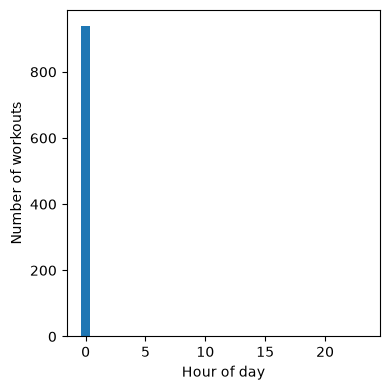

In [162]:
plt.bar(by_hour['Hour of day'], by_hour['Total workouts'])
plt.ylabel('Number of workouts')
plt.xlabel('Hour of day')
plt.tight_layout()
plt.savefig('./img/workouts_by_hour_of_day.png')
plt.show()

## By day of week

We count workouts by day of week.

In [163]:
by_day = df[['startTime', 'sport']].copy()
by_day['Day of week'] = pd.to_datetime(by_day['startTime']).dt.day_name()
by_day['Day number'] = pd.to_datetime(by_day['startTime']).dt.dayofweek
by_day = by_day.groupby(['Day of week', 'Day number'], as_index=False)
by_day = by_day.count()
by_day = by_day.drop('startTime', axis=1)
by_day = by_day.sort_values('Day number')
by_day = by_day.rename(columns={'sport': 'Total Workouts'})

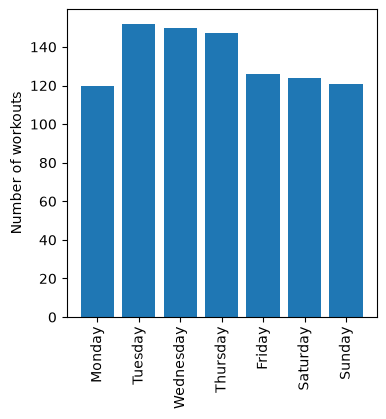

In [164]:
plt.bar(by_day['Day of week'], by_day['Total Workouts'])
plt.xticks(rotation=90)
plt.ylabel('Number of workouts')
plt.savefig('./img/workouts_by_day_of_week.png')
plt.show()

## Scatter plot of walks data

We plot `totalTime` versus `kiloCalories`. As can be seen their seems to exist a linear relationship between the two.

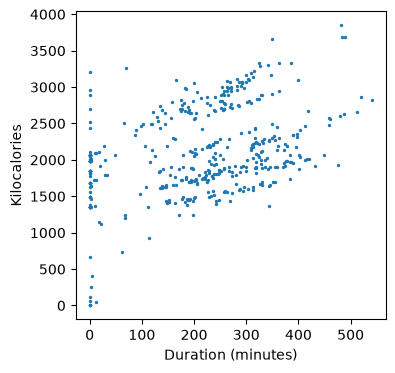

In [165]:
walking = df[df['sport'] == 'walking']
plt.scatter(walking['totalTime'], walking['kiloCalories'], s=2)
plt.xlabel('Duration (minutes)')
plt.ylabel('Kilocalories')
plt.savefig('./img/walks_kilocalories_vs_time.png')
plt.show()

We plot `heartRateAvg` against `kiloCalories`. Again we see a linear relationship although there are a couple of outliers

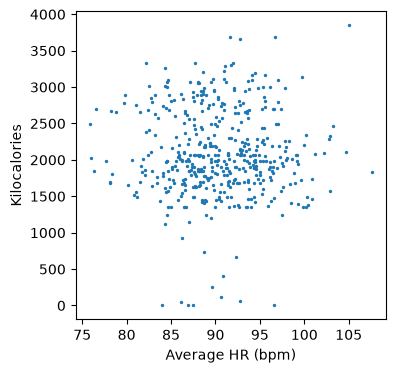

In [166]:
walking = df[df['sport'] == 'walking']
plt.scatter(walking['heartRateAvg'], walking['kiloCalories'], s=2)
plt.ylabel('Kilocalories')
plt.xlabel('Average HR (bpm)')
plt.savefig('./img/walks_kilocalories_vs_avg_hr.png')
plt.show()

# Regression

## Data preparation

Now we proceed to build a regression model to predict `kiloCalories` burned during a workout. First we create a subset of the original data.

In [167]:
reg_df = df[['kiloCalories', 'totalTime', 
             'heartRateQ99', 'isStrength', 'sport']].copy()

In [168]:
reg_df.head()

,kiloCalories,totalTime,heartRateQ99,isStrength,sport
0,1985,366,145.66,False,cycling
1,1797,257,140.43,False,cycling
2,1776,222,133.44,False,cycling
3,1745,272,141.86,False,cycling
4,1863,267,147.98,False,treadmill_running


We remove the rows where `sport` is `running` because there were only two workouts recorded during the period in question.

In [169]:
reg_df = reg_df[reg_df['sport'] != 'running']

### Outliers

The data is cleansed of outliers using interquartile range.

In [170]:
def is_outlier_iqr(series, k=1.5):
    """
    Check if value is an outlier
    using interquartile range.
    """
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)        
    iqr = q3 - q1
    is_outlier = (series <= q1 - k * iqr) | (q3 + k * iqr <= series)
    
    return is_outlier

In [171]:
time_mask = is_outlier_iqr(series=reg_df['totalTime'])
kcal_mask = is_outlier_iqr(series=reg_df['kiloCalories'])
hr_mask = is_outlier_iqr(series=reg_df['heartRateQ99'])

In [172]:
reg_df = reg_df[~(time_mask | kcal_mask | hr_mask)]

## Histograms

We proceed to visualize histograms of each of the variables.

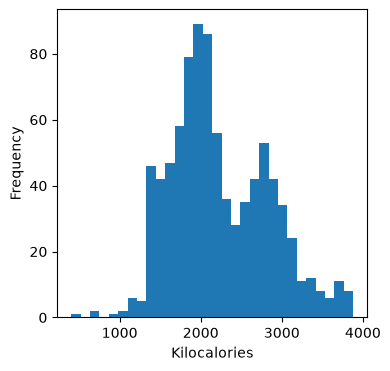

In [173]:
plt.hist(reg_df['kiloCalories'], bins=30)
plt.xlabel('Kilocalories')
plt.ylabel('Frequency')
plt.savefig('./img/kilocalories_histogram.png')
plt.show()

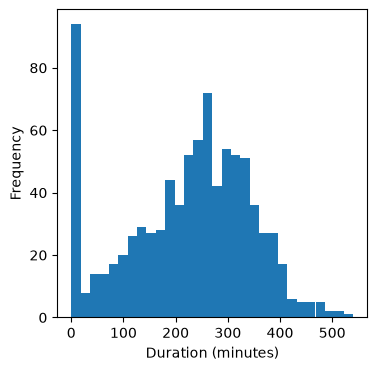

In [174]:
plt.hist(reg_df['totalTime'], bins=30)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.savefig('./img/duration_histogram.png')
plt.show()

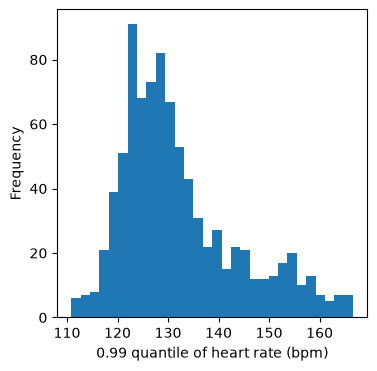

In [175]:
plt.hist(reg_df['heartRateQ99'], bins=30)
plt.xlabel('0.99 quantile of heart rate (bpm)')
plt.ylabel('Frequency')
plt.savefig('./img/q99_hr_histogram.png')
plt.show()

## Scatter plots

The plot below gives reason to suspect a linear relationship between `kiloCalories` and `totalTime`.

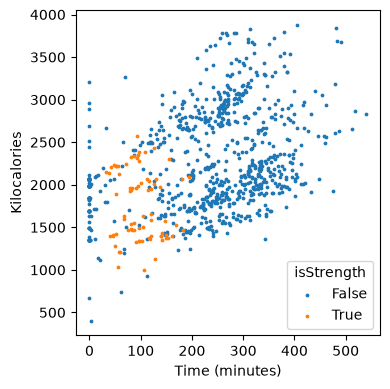

In [176]:
for val in [False, True]:
    tmp = reg_df[reg_df['isStrength'] == val]
    plt.scatter(tmp['totalTime'], 
                tmp['kiloCalories'],
                s=3, 
                label=val)
    
plt.xlabel('Time (minutes)')    
plt.ylabel('Kilocalories')    
plt.legend(title='isStrength', loc='best')
plt.tight_layout()
plt.savefig('./img/time_vs_kilocalories_scatter_by_strength.png')
plt.show()

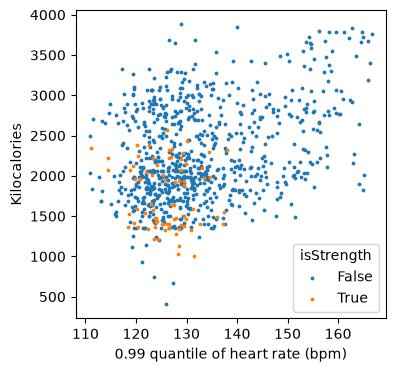

In [177]:
for val in [False, True]:
    tmp = reg_df[reg_df['isStrength'] == val]
    plt.scatter(tmp['heartRateQ99'],
                tmp['kiloCalories'],
                s=3, 
                label=val)

plt.xlabel('0.99 quantile of heart rate (bpm)')    
plt.ylabel('Kilocalories')
plt.legend(title='isStrength', loc='best')
plt.savefig('./img/99q_hr_vs_kilocalories_scatter_by_strength.png')
plt.show()

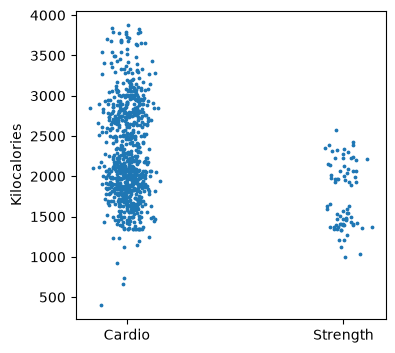

In [178]:
plt.scatter(reg_df['isStrength'] + np.random.normal(scale=1/20, size=len(reg_df)), 
            reg_df['kiloCalories'], s=3)

plt.ylabel('Kilocalories')
plt.xticks(ticks=[0, 1], labels=['Cardio', 'Strength'])
plt.savefig('./img/is_strength_vs_kilocalories_jitter.png')
plt.show()

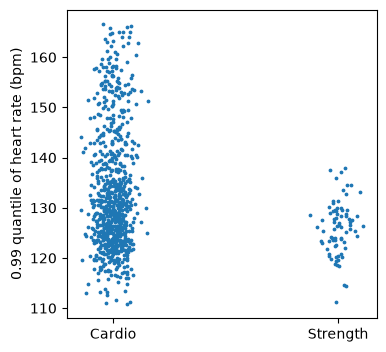

In [179]:
plt.scatter(reg_df['isStrength'] + np.random.normal(scale=1/20, size=len(reg_df)), 
            reg_df['heartRateQ99'], s=3)

plt.ylabel('0.99 quantile of heart rate (bpm)')
plt.xticks(ticks=[0, 1], labels=['Cardio', 'Strength'])
plt.savefig('./img/is_strength_vs_99q_hr_scatter.png')
plt.show()

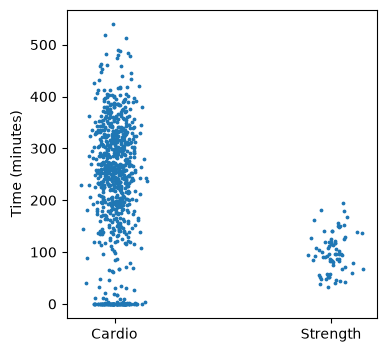

In [180]:
plt.scatter(reg_df['isStrength'] + np.random.normal(scale=1/20, size=len(reg_df)), 
            reg_df['totalTime'], s=3)

plt.ylabel('Time (minutes)')
plt.xticks(ticks=[0, 1], labels=['Cardio', 'Strength'])
plt.savefig('./img/is_strength_vs_time_jitter.png')
plt.show()

## Correlation

We convert binary the feature `isStrength` to integers for the rest of the analysis.

In [181]:
reg_df['isStrength'] = reg_df['isStrength'].astype(int)

We inspect the correlation matrix to check for multicollinearity. It should be noted that the correlation between `kiloCalories` and `totalTime` is quite high and this to be expected.

In [183]:
C = reg_df.corr(method='pearson', numeric_only=True)
# C = C.style.background_gradient(cmap='YlGn')
# C = C.set_precision(2)
C

,kiloCalories,totalTime,heartRateQ99,isStrength
kiloCalories,1.00,0.40,0.36,-0.25
totalTime,0.40,1.00,0.28,-0.32
heartRateQ99,0.36,0.28,1.00,-0.17
isStrength,-0.25,-0.32,-0.17,1.00


## Multicollinearity

We inspect the respect variance inflation factors and are happy to see that all are below 10.

In [184]:
tmp = reg_df.drop(['kiloCalories', 'sport'], axis=1)

vifs = []
for i in range(tmp.shape[1]):
    vif = variance_inflation_factor(tmp.to_numpy(), i)
    vifs.append(round(vif, 2))
    
vifs = pd.DataFrame(vifs, index=tmp.columns, columns=['VIF'])
vifs = vifs.sort_values('VIF', ascending=False)
vifs = vifs.reset_index()
vifs = vifs.rename(columns={'index': 'Variable'})

# vifs = vifs.style.background_gradient(cmap='OrRd')
# vifs = vifs.set_precision(2)

vifs

,Variable,VIF
0,heartRateQ99,5.57
1,totalTime,5.20
2,isStrength,1.20


## Modelling

Before the actual modelling we prepare a function to calculate `RMSE` to compare models and extract the true `kiloCalories` into a separate array.

In [185]:
y_true = reg_df['kiloCalories'].to_numpy()

In [186]:
def calc_rmse(y_true, y_pred):
    x = np.sqrt(np.mean(np.power(y_true - y_pred, 2)))
    return round(x, 4)

In [187]:
all_results = []

### Time only

We start the modelling section of by building the simplest model that comes to mind: predict `kiloCalories` using `totalTime`.

In [188]:
formula = 'kiloCalories ~ totalTime'
mdl_time = smf.ols(formula=formula, data=reg_df)
mdl_time = mdl_time.fit()
mdl_time.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.162     
Dependent Variable: kiloCalories     AIC:                13443.1303
Date:               2026-09-16 20:09 BIC:                13452.6673
No. Observations:   870              Log-Likelihood:     -6719.6   
Df Model:           1                F-statistic:        169.2     
Df Residuals:       868              Prob (F-statistic): 1.78e-35  
R-squared:          0.163            Scale:              3.0005e+05
-------------------------------------------------------------------
                Coef.   Std.Err.    t    P>|t|    [0.025    0.975] 
-------------------------------------------------------------------
Intercept     1783.5099  39.0284 45.6978 0.0000 1706.9089 1860.1109
totalTime        2.0035   0.1540 13.0089 0.0000    1.7012    2.3058
-------------------------------------------------------------------
Omnibus:              49.799        Durbin-Watson:           0.358 
Prob(Omnibus):        0.000         Jarque-Bera (JB):        40.600
Skew:                 0.446         Prob(JB):                0.000 
Kurtosis:             2.430         Condition No.:           533   
===================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors
is correctly specified.
"""

In [189]:
y_pred = mdl_time.predict(reg_df)
rmse = calc_rmse(y_pred, y_true)
all_results.append((rmse, formula))

In [190]:
print(rmse)

547.1372


### By sport

The next regression we are going to do will be univariate regression separately for each sport, this will help us answer the question which sport is the most effective at burning calories during a workout.

In [191]:
all_sports = sorted(reg_df['sport'].unique())
reg_sports_res = []

# For all sport do simple linear regression
for sport in all_sports:
    tmp = reg_df[reg_df['sport'] == sport]
    formula = 'kiloCalories ~ totalTime'
    mdl_sport = smf.ols(formula=formula, data=tmp)
    mdl_sport = mdl_sport.fit()
    sport_stats = [formula, sport] + list(mdl_sport.params) + [mdl_sport.rsquared]    
    reg_sports_res.append(sport_stats)
    
cols = ['Formula', 'Sport', 'Intercept', 'Slope', 'R squared']

reg_sports_res = pd.DataFrame(reg_sports_res, columns=cols)    
reg_sports_res = reg_sports_res.sort_values(['Slope'], ascending=False)
reg_sports_res = reg_sports_res.reset_index(drop=True)

readme_df = reg_sports_res.copy().round(2)

# reg_sports_res = reg_sports_res.style.background_gradient(cmap='YlGn', subset='Slope')
# reg_sports_res = reg_sports_res.set_precision(2)

reg_sports_res

,Formula,Sport,Intercept,Slope,R squared
0,kiloCalories ~ totalTime,walking,"1,811.45",1.51,0.14
1,kiloCalories ~ totalTime,treadmill_running,"2,241.33",1.38,0.03
2,kiloCalories ~ totalTime,cycling,"1,964.73",1.32,0.04
3,kiloCalories ~ totalTime,strength_training,"1,864.10",-1.12,0.01


## Time and heart rate

We try to enhance the model by adding `heartRateQ99`.

In [192]:
formula = 'kiloCalories ~ totalTime + heartRateQ99'
mdl_time_and_hr = smf.ols(formula=formula, data=reg_df)
mdl_time_and_hr = mdl_time_and_hr.fit()
mdl_time_and_hr.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.230     
Dependent Variable: kiloCalories     AIC:                13370.1767
Date:               2026-09-16 20:09 BIC:                13384.4822
No. Observations:   870              Log-Likelihood:     -6682.1   
Df Model:           2                F-statistic:        131.1     
Df Residuals:       867              Prob (F-statistic): 1.76e-50  
R-squared:          0.232            Scale:              2.7560e+05
-------------------------------------------------------------------
                  Coef.  Std.Err.    t    P>|t|    [0.025   0.975] 
-------------------------------------------------------------------
Intercept         3.4129 204.9884  0.0166 0.9867 -398.9186 405.7445
totalTime         1.6298   0.1535 10.6145 0.0000    1.3284   1.9312
heartRateQ99     14.0913   1.5955  8.8322 0.0000   10.9599  17.2228
-------------------------------------------------------------------
Omnibus:              83.222        Durbin-Watson:           0.321 
Prob(Omnibus):        0.000         Jarque-Bera (JB):        39.135
Skew:                 0.337         Prob(JB):                0.000 
Kurtosis:             2.209         Condition No.:           3233  
===================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors
is correctly specified.
[2] The condition number is large, 3.23e+03. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [193]:
y_pred = mdl_time_and_hr.predict(reg_df)
rmse = calc_rmse(y_pred, y_true)
all_results.append((rmse, formula))

In [194]:
print(rmse)

524.0687


## Time with random effects by workout type

In [211]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# 1. Silence the messy warning boxes
warnings.simplefilter('ignore', ConvergenceWarning)

formula = 'kiloCalories ~ totalTime + heartRateQ99'
re_formula = ' ~ totalTime'
group = 'isStrength'

mdl_time_with_hr_re = smf.mixedlm(formula=formula, 
                                  data=reg_df, 
                                  groups=reg_df[group], 
                                  re_formula=re_formula)

# 2. Swap the optimizer to 'powell' which handles our bridged data much better
mdl_time_with_hr_re = mdl_time_with_hr_re.fit(method='powell')
mdl_time_with_hr_re.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Mixed Linear Model Regression Results
===================================================================
Model:               MixedLM    Dependent Variable:    kiloCalories
No. Observations:    870        Method:                REML        
No. Groups:          2          Scale:                 271122.1102 
Min. group size:     77         Log-Likelihood:        -6672.1670  
Max. group size:     793        Converged:             Yes         
Mean group size:     435.0                                         
-------------------------------------------------------------------
                       Coef.  Std.Err.   z   P>|z|  [0.025   0.975]
-------------------------------------------------------------------
Intercept             115.481  298.859 0.386 0.699 -470.271 701.233
totalTime               0.384    2.456 0.156 0.876   -4.430   5.198
heartRateQ99           13.617    1.596 8.531 0.000   10.488  16.745
Group Var               0.005   36.450                             
Group x totalTime Cov  -0.007    1.441                             
totalTime Var           2.645    0.014                             
===================================================================

"""

In [212]:
y_pred = mdl_time_with_hr_re.predict(reg_df)
rmse = calc_rmse(y_pred, y_true)
all_results.append((rmse, formula, re_formula, group))

In [213]:
print(rmse)

591.4712


## Model evaluation

We compare the linear models created earlier:

In [214]:
comp_df = pd.DataFrame(all_results, columns=['RMSE', 'Formula', 'Random effects', 'Groups'])
comp_df = comp_df.sort_values('RMSE')

# comp_df = comp_df.style.background_gradient(cmap='OrRd', subset='RMSE')
# comp_df = comp_df.set_precision(2)

comp_df

,RMSE,Formula,Random effects,Groups
1,524.07,kiloCalories ~ totalTime + heartRateQ99,NaN,NaN
0,547.14,kiloCalories ~ totalTime,NaN,NaN
3,591.47,kiloCalories ~ totalTime + heartRateQ99,~ totalTime,isStrength
2,600.80,kiloCalories ~ totalTime + heartRateQ99,~ totalTime,isStrength


For further evaluation we choose the random effects model.

In [215]:
mdl = mdl_time_with_hr_re
residuals = mdl_time_with_hr_re.resid

### Visual inspection

We proceed to inspect the residuals of the model. First we view the histogram of the residuals. It can be seen that it looks normal.

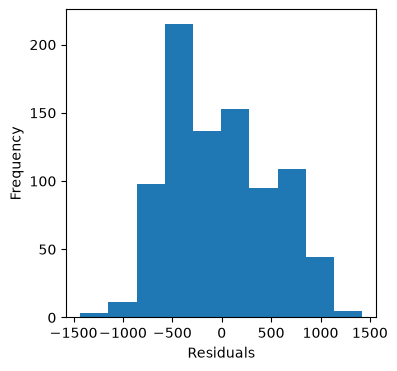

In [216]:
plt.hist(residuals)
plt.ylabel('Frequency')
plt.xlabel('Residuals')
plt.savefig('./img/mdl_residuals.png')
plt.show()

The next plot is a qqplot created to visually inspect the normality of the residuals. We see 3 nasty outliers in the top right corner.

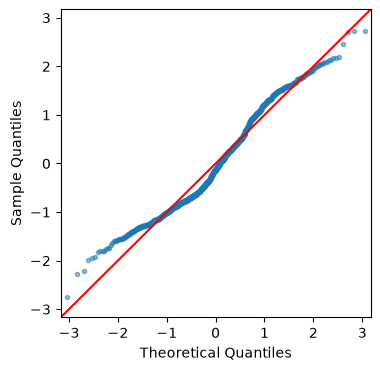

In [217]:
plt.figure()
ax = plt.gca()

qqplot(data=mdl.resid,
       ax=ax,
       markersize=3,
       line='45',
       fit=True,
       alpha=1/2)

plt.savefig('./img/mdl_qq.png')
plt.show()

The third plot we make is a plot of the standardized residuals to check for homoskedasticity. Again we see the same outliers as on the plot above.

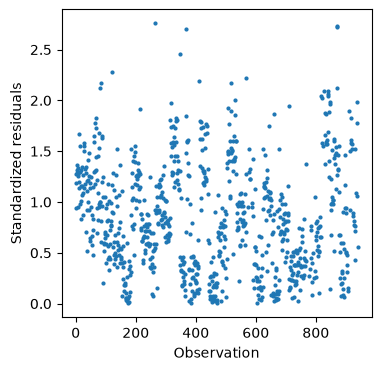

In [218]:
residuals_std = np.abs((residuals - np.mean(residuals)) / np.std(residuals))
plt.plot(residuals_std, 'o', markersize=2)
plt.xlabel('Observation')
plt.ylabel('Standardized residuals')
plt.savefig('./img/mdl_residuals_std.png')
plt.show()

Finally we compare the predicted `kiloCalories` with the actual values.

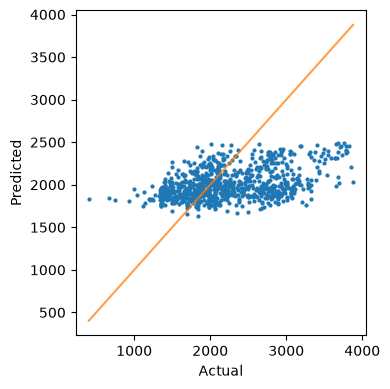

In [219]:
y_pred = mdl.predict(reg_df)
y_pred = y_pred.to_numpy().reshape(len(y_pred))

m = np.min(np.hstack([y_true, y_pred]))
M = np.max(np.hstack([y_true, y_pred]))

x = np.linspace(m, M, len(y_pred))
plt.plot(y_true, y_pred, 'o', markersize=2)
plt.plot(x,x, alpha=3/4)
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.tight_layout()
plt.savefig('./img/mdl_predicted_vs_actual.png')
plt.show()

The next step is to take a look at the data points with the biggest error. As can be seen the model has issues predicting strength training workouts.

In [220]:
errors = reg_df.copy()
errors['kiloCaloriesPredicted'] = mdl.predict(reg_df)

errors['error'] = np.abs(errors['kiloCalories'] - errors['kiloCaloriesPredicted'])

errors = errors.sort_values('error', ascending=False)
errors = errors.reset_index(drop=True)

order = ['kiloCaloriesPredicted',
         'kiloCalories', 
         'error',
         'totalTime',
         'isStrength']

errors = errors[order]

errors = errors.head(5)

errors = errors.style.background_gradient(cmap='OrRd', subset='error')
errors = errors.format(precision=2)

errors

,kiloCaloriesPredicted,kiloCalories,error,totalTime,isStrength
0,2026.91,3879,1852.09,405,0
1,2025.13,3691,1665.87,483,0
2,1989.44,3654,1664.56,350,0
3,2207.45,3846,1638.55,482,0
4,2096.97,3683,1586.03,490,0


# Summary

In [221]:
# Make table for README
# print(tabulate.tabulate(by_sport.values, by_sport.columns, tablefmt="pipe"))

In [222]:
# Make table for README
# print(tabulate.tabulate(readme_df.values, readme_df.columns, tablefmt="pipe"))

* In this project, I defined a daily record as an instance of tracking physical activity.
* I utilized a public Fitbit daily activity dataset from Kaggle to track steps, active minutes, and calorie burn.
* The data was loaded, transformed, and cleaned using `pandas` and Python.
* The clean dataset contains `940` entries, mapping daily activity metrics over the observation period.

| Sport             |   Total kilocalories |   Total kilograms |
|:------------------|---------------------:|------------------:|
| walking           |               972252 |            126.27 |
| treadmill_running |               698197 |             90.67 |
| cycling           |               359896 |             46.74 |
| strength_training |               135048 |             17.54 |

* After transforming the data, I found that daily activity duration and calories burned exhibit a strong positive correlation.
* Multiple linear regressions and mixed-effects models were successfully trained and evaluated to predict calorie expenditure based on activity time and synthesized intensity metrics.